# 🧠 Strategist Agent — AI Career Rejection Analyst

**Pipeline Stage: Skills Gap Analysis → Match Scoring → 30-Day Roadmap**

This notebook takes a **parsed Resume (JSON)** and a **parsed Job Description (JSON)**, then:
1. Extracts skills from both documents
2. Computes a **weighted match score** (0–100)
3. Identifies the **skills gap** (missing skills by priority)
4. Generates a **30-day learning roadmap** via Mistral AI
5. Produces **professional charts** and a **multi-page PDF report**

---

## 📦 Step 1: Setup & Dependencies

In [ ]:
%pip install mistralai python-dotenv fpdf2 matplotlib numpy -q

import json
import os
import re
import tempfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime
from dotenv import load_dotenv
from mistralai import Mistral
from fpdf import FPDF
from fpdf.enums import XPos, YPos
from IPython.display import display, Markdown

print('✅ All dependencies installed and imported.')

✅ All dependencies installed and imported.


## 🔑 Step 2: Mistral Client Setup
Loads `MISTRAL_API_KEY` from the project `.env` file and initializes the client.

In [2]:
load_dotenv(dotenv_path=os.path.join('..', '..', '.env'))

MISTRAL_API_KEY = os.environ.get('MISTRAL_API_KEY', '').strip()

if not MISTRAL_API_KEY:
    raise ValueError(
        '❌ MISTRAL_API_KEY not found! '
        'Add it to your .env file: MISTRAL_API_KEY=your_key_here'
    )

client = Mistral(api_key=MISTRAL_API_KEY)
MODEL = 'mistral-small-latest'

print(f'✅ Mistral client initialized (key: {MISTRAL_API_KEY[:6]}...{MISTRAL_API_KEY[-4:]})')
print(f'   Model: {MODEL}')

✅ Mistral client initialized (key: kNVCjm...YmSX)
   Model: mistral-small-latest


## 📄 Step 3: Mock Resume Data (Parsed JSON)
This is the structured resume output from the earlier OCR → Parser stage.

In [3]:
mock_resume = {
    'name': 'John Doe',
    'title': 'Data Scientist',
    'sections': {
        'summary': {
            'paragraphs': [
                'Highly motivated and experienced Data Scientist with a strong background in machine learning, '
                'data analysis, and database administration. Proven track record of delivering high-quality '
                'projects and driving business growth through data-driven insights.'
            ]
        },
        'experience': {
            'subsections': {
                'senior_data_scientist': {
                    'bullet_points': [
                        'Jan 2020 - Present', 'New York, USA',
                        'Developed and deployed machine learning models using Python, R, and SQL',
                        'Designed and implemented data pipelines using Apache Beam, Apache Spark, and AWS Glue',
                        'Collaborated with data engineers to optimize database performance'
                    ],
                    'paragraphs': [
                        '### ABC Corporation',
                        'Led a team of data scientists to develop predictive models that increased sales by 25%.'
                    ]
                },
                'data_scientist': {
                    'bullet_points': [
                        'Jun 2018 - Dec 2019', 'San Francisco, USA',
                        'Developed and deployed machine learning models using Python, R, and SQL',
                        'Collaborated with data engineers to design and implement data pipelines',
                        'Worked with business stakeholders to identify data-driven solutions'
                    ],
                    'paragraphs': [
                        '### DEF Startups',
                        'Worked on customer segmentation, churn prediction, and recommendation systems.'
                    ]
                }
            }
        },
        'projects': {
            'subsections': {
                'customer_segmentation': {
                    'bullet_points': ['Mar 2020 - Jun 2020', 'Python', 'R', 'SQL', 'Apache Spark'],
                    'paragraphs': ['Lead Data Scientist', 'Customer segmentation using clustering algorithms.']
                },
                'churn_prediction': {
                    'bullet_points': ['Sep 2019 - Dec 2019', 'Python', 'R', 'SQL', 'Apache Spark'],
                    'paragraphs': ['Data Scientist', 'Churn prediction model reducing customer churn by 20%.']
                }
            }
        },
        'skills': {
            'bullet_points': [
                'Machine Learning', 'Data Analysis', 'Database Administration',
                'Python', 'R', 'SQL', 'Apache Spark', 'Communication', 'Team Management'
            ]
        },
        'education': {
            'subsections': {
                "master's": {
                    'bullet_points': ['Jun 2018', 'Stanford, USA'],
                    'paragraphs': ['Stanford University', 'Data Science • 3.8']
                }
            }
        }
    }
}

print(f"✅ Resume loaded: {mock_resume['name']} — {mock_resume['title']}")
print(f"   Listed skills: {', '.join(mock_resume['sections']['skills']['bullet_points'])}")

✅ Resume loaded: John Doe — Data Scientist
   Listed skills: Machine Learning, Data Analysis, Database Administration, Python, R, SQL, Apache Spark, Communication, Team Management


## 📋 Step 4: Mock Job Description Data (Parsed JSON)
A realistic **Senior ML Engineer** JD that creates a meaningful skills gap.

In [ ]:
mock_jd = {
    'job_title': 'Senior Machine Learning Engineer',
    'company': 'TechVision AI',
    'location': 'New York, USA (Hybrid)',
    'description': 'We are seeking a Senior ML Engineer to design, build, and deploy production-grade ML systems.',
    'requirements': {
        'required_skills': [
            'Python', 'Machine Learning', 'Deep Learning', 'PyTorch', 'SQL',
            'Docker', 'Kubernetes', 'MLflow', 'CI/CD Pipelines', 'REST APIs'
        ],
        'preferred_skills': [
            'Apache Spark', 'TensorFlow', 'AWS (SageMaker, Lambda, S3)',
            'Terraform', 'Data Analysis', 'LLM Fine-tuning'
        ],
        'nice_to_have': ['Rust', 'Go', 'Graph Neural Networks', 'Team Management']
    },
    'experience_required': '5+ years in ML/Data Science, 2+ years in ML Engineering',
    'education': 'MS or PhD in Computer Science, Data Science, or related field',
    'responsibilities': [
        'Design and implement scalable ML pipelines for training and inference',
        'Deploy models to production using Docker, Kubernetes, and cloud platforms',
        'Build monitoring and alerting systems for model performance drift',
        'Implement A/B testing frameworks for model evaluation',
        'Maintain ML infrastructure and CI/CD pipelines'
    ]
}

print(f"✅ Job Description loaded: {mock_jd['job_title']} @ {mock_jd['company']}")
print(f"   Required skills:  {len(mock_jd['requirements']['required_skills'])}")
print(f"   Preferred skills: {len(mock_jd['requirements']['preferred_skills'])}")
print(f"   Nice-to-have:     {len(mock_jd['requirements']['nice_to_have'])}")

✅ Job Description loaded: Senior Machine Learning Engineer @ TechVision AI
   Required skills:  10
   Preferred skills: 6
   Nice-to-have:     4


## 🔍 Step 5: Skills Extraction
Extract all candidate skills from the resume (skills section + experience + projects)  
and all JD requirements organized by priority.

In [5]:
# ─── KNOWN SKILL KEYWORDS ───────────────────────────────────────────────────
SKILL_KEYWORDS = {
    'python', 'r', 'sql', 'java', 'scala', 'go', 'rust', 'c++',
    'machine learning', 'deep learning', 'data analysis', 'data science',
    'pytorch', 'tensorflow', 'keras', 'scikit-learn',
    'apache spark', 'apache beam', 'apache kafka', 'apache airflow',
    'docker', 'kubernetes', 'terraform', 'ci/cd pipelines', 'ci/cd',
    'aws', 'aws glue', 'aws sagemaker', 'azure', 'gcp',
    'mlflow', 'mlops', 'rest apis', 'fastapi', 'flask',
    'database administration', 'data pipelines', 'etl',
    'communication', 'team management', 'leadership',
    'llm fine-tuning', 'natural language processing', 'nlp',
    'computer vision', 'graph neural networks',
    'a/b testing', 'statistical analysis', 'hypothesis testing',
    'recommendation systems', 'clustering', 'predictive models',
    'customer segmentation', 'churn prediction'
}


def normalize(skill: str) -> str:
    return skill.strip().lower()


def extract_skills_from_text(text: str, known_skills: set) -> set:
    text_lower = text.lower()
    found = set()
    for skill in known_skills:
        if len(skill) <= 2:
            if re.search(rf'\b{re.escape(skill)}\b', text_lower):
                found.add(skill)
        else:
            if skill in text_lower:
                found.add(skill)
    return found


def extract_candidate_skills(resume: dict) -> set:
    skills = set()
    sections = resume.get('sections', {})
    if 'skills' in sections:
        for s in sections['skills'].get('bullet_points', []):
            skills.add(normalize(s))
    if 'experience' in sections:
        for role, content in sections['experience'].get('subsections', {}).items():
            for bp in content.get('bullet_points', []):
                skills |= extract_skills_from_text(bp, SKILL_KEYWORDS)
            for para in content.get('paragraphs', []):
                skills |= extract_skills_from_text(para, SKILL_KEYWORDS)
    if 'projects' in sections:
        for proj, content in sections['projects'].get('subsections', {}).items():
            for bp in content.get('bullet_points', []):
                skills |= extract_skills_from_text(bp, SKILL_KEYWORDS)
            for para in content.get('paragraphs', []):
                skills |= extract_skills_from_text(para, SKILL_KEYWORDS)
    return skills


def extract_jd_requirements(jd: dict) -> dict:
    reqs = jd.get('requirements', {})
    return {
        'required':     {normalize(s) for s in reqs.get('required_skills', [])},
        'preferred':    {normalize(s) for s in reqs.get('preferred_skills', [])},
        'nice_to_have': {normalize(s) for s in reqs.get('nice_to_have', [])}
    }


candidate_skills = extract_candidate_skills(mock_resume)
jd_requirements  = extract_jd_requirements(mock_jd)

print('=' * 60)
print('📊 SKILLS EXTRACTION RESULTS')
print('=' * 60)
print(f'\n🧑 Candidate skills found ({len(candidate_skills)}):')
for s in sorted(candidate_skills):
    print(f'   • {s.title()}')
for tier_label, tier_key in [('JD Required', 'required'), ('JD Preferred', 'preferred'), ('JD Nice-to-Have', 'nice_to_have')]:
    print(f'\n📋 {tier_label} ({len(jd_requirements[tier_key])}):') 
    for s in sorted(jd_requirements[tier_key]):
        print(f'   • {s.title()}')

📊 SKILLS EXTRACTION RESULTS

🧑 Candidate skills found (18):
   • Apache Beam
   • Apache Spark
   • Aws
   • Aws Glue
   • Churn Prediction
   • Clustering
   • Communication
   • Customer Segmentation
   • Data Analysis
   • Data Pipelines
   • Database Administration
   • Machine Learning
   • Predictive Models
   • Python
   • R
   • Recommendation Systems
   • Sql
   • Team Management

📋 JD Required (10):
   • Ci/Cd Pipelines
   • Deep Learning
   • Docker
   • Kubernetes
   • Machine Learning
   • Mlflow
   • Python
   • Pytorch
   • Rest Apis
   • Sql

📋 JD Preferred (6):
   • Apache Spark
   • Aws (Sagemaker, Lambda, S3)
   • Data Analysis
   • Llm Fine-Tuning
   • Tensorflow
   • Terraform

📋 JD Nice-to-Have (4):
   • Go
   • Graph Neural Networks
   • Rust
   • Team Management


## ⚖️ Step 6: Weighted Match Score Calculation

**Scoring weights:**
| Tier | Weight | Reasoning |
|------|--------|-----------|
| Required | 1.0 | Must-have — makes or breaks the application |
| Preferred | 0.5 | Strong differentiator |
| Nice-to-Have | 0.25 | Bonus points |

In [6]:
WEIGHTS = {'required': 1.00, 'preferred': 0.50, 'nice_to_have': 0.25}


def fuzzy_match(candidate_skill: str, jd_skill: str) -> bool:
    a, b = normalize(candidate_skill), normalize(jd_skill)
    if a == b:
        return True
    if a in b or b in a:
        return True
    a_words = {w for w in a.split() if len(w) >= 3}
    b_words = {w for w in b.split() if len(w) >= 3}
    if a_words and b_words and a_words & b_words:
        return True
    return False


def calculate_match_score(candidate_skills: set, jd_requirements: dict) -> dict:
    breakdown = {}
    total_weighted = 0
    max_weighted = 0
    all_missing = []

    for tier, jd_skills in jd_requirements.items():
        weight = WEIGHTS[tier]
        matched, missing = [], []

        for jd_skill in sorted(jd_skills):
            found = any(fuzzy_match(cs, jd_skill) for cs in candidate_skills)
            (matched if found else missing).append(jd_skill)

        tier_max   = len(jd_skills) * weight
        tier_score = len(matched) * weight
        tier_pct   = (len(matched) / len(jd_skills) * 100) if jd_skills else 0

        total_weighted += tier_score
        max_weighted   += tier_max

        breakdown[tier] = {
            'matched':       matched,
            'missing':       missing,
            'weight':        weight,
            'matched_count': len(matched),
            'total_count':   len(jd_skills),
            'tier_pct':      round(tier_pct, 1)
        }
        all_missing.extend([(s, tier, weight) for s in missing])

    overall = (total_weighted / max_weighted * 100) if max_weighted else 0
    return {
        'overall_score':       round(overall, 1),
        'max_possible_score':  max_weighted,
        'raw_weighted_score':  total_weighted,
        'breakdown':           breakdown,
        'all_missing':         all_missing
    }


score_result = calculate_match_score(candidate_skills, jd_requirements)

print('=' * 60)
print('⚖️  WEIGHTED MATCH SCORE')
print('=' * 60)
score = score_result['overall_score']
bar_len = 30
filled = int(bar_len * score / 100)
bar = '█' * filled + '░' * (bar_len - filled)
print(f'\n   [{bar}] {score}%\n')

for tier_name, tier_data in score_result['breakdown'].items():
    label = tier_name.replace('_', ' ').title()
    m, t = tier_data['matched_count'], tier_data['total_count']
    print(f'\n── {label} (weight {tier_data["weight"]}) ─ {m}/{t} matched ({tier_data["tier_pct"]}%)')
    if tier_data['matched']:
        print(f'   ✅ Matched: {", ".join(s.title() for s in tier_data["matched"])}')
    if tier_data['missing']:
        print(f'   ❌ Missing: {", ".join(s.title() for s in tier_data["missing"])}')

print(f'\n{"=" * 60}')
print(f'📊 Total weighted: {score_result["raw_weighted_score"]:.2f} / {score_result["max_possible_score"]:.2f}')

⚖️  WEIGHTED MATCH SCORE

   [██████████████████████████░░░░] 87.5%


── Required (weight 1.0) ─ 9/10 matched (90.0%)
   ✅ Matched: Ci/Cd Pipelines, Deep Learning, Docker, Kubernetes, Machine Learning, Python, Pytorch, Rest Apis, Sql
   ❌ Missing: Mlflow

── Preferred (weight 0.5) ─ 5/6 matched (83.3%)
   ✅ Matched: Apache Spark, Aws (Sagemaker, Lambda, S3), Data Analysis, Tensorflow, Terraform
   ❌ Missing: Llm Fine-Tuning

── Nice To Have (weight 0.25) ─ 3/4 matched (75.0%)
   ✅ Matched: Graph Neural Networks, Rust, Team Management
   ❌ Missing: Go

📊 Total weighted: 12.25 / 14.00


## 🤖 Step 7: Mistral AI — Gap Analysis & 30-Day Roadmap
Sends the skills gap to Mistral and receives a structured learning roadmap.

In [7]:
def build_roadmap_prompt(resume: dict, jd: dict, score_result: dict) -> str:
    missing_by_tier = {}
    for skill, tier, weight in score_result['all_missing']:
        missing_by_tier.setdefault(tier, []).append(skill.title())

    missing_section = ''
    for tier in ['required', 'preferred', 'nice_to_have']:
        if tier in missing_by_tier:
            label = tier.replace('_', ' ').title()
            missing_section += f"  - {label}: {', '.join(missing_by_tier[tier])}\n"

    matched_skills = []
    for tier_data in score_result['breakdown'].values():
        matched_skills.extend(s.title() for s in tier_data['matched'])

    return f"""## Candidate Profile
- **Name**: {resume['name']}
- **Current Title**: {resume['title']}
- **Existing Skills**: {', '.join(matched_skills)}
- **Match Score**: {score_result['overall_score']}%

## Target Role
- **Position**: {jd['job_title']}
- **Company**: {jd['company']}

## Skills Gap (Missing Skills)
{missing_section}
## Task
Based on the candidate's existing skills and the missing skills above,
generate a **detailed 30-day learning roadmap** to close the gap.

Structure your response EXACTLY as follows:

### Gap Analysis Summary
A brief analysis of the candidate's strengths vs. the role's requirements.

### 30-Day Learning Roadmap

#### Week 1: [Theme]
- Day 1-2: [Topic] — [specific activities, resources]
- Day 3-5: [Topic] — [specific activities, resources]
- Day 6-7: [Hands-on project or review]

#### Week 2: [Theme]
(same format)

#### Week 3: [Theme]
(same format)

#### Week 4: [Theme]
(same format)

### Milestones & Success Metrics
- End of Week 1: [measurable outcome]
- End of Week 2: [measurable outcome]
- End of Week 3: [measurable outcome]
- End of Week 4: [measurable outcome]

### Recommended Resources
Top courses, books, and tools for each missing skill.

### Daily Time Commitment
Suggested hours per day and optimal schedule.
"""


SYSTEM_PROMPT = (
    'You are an expert AI Career Strategist. Your specialty is analyzing skills gaps between '
    'candidates and job descriptions, then creating actionable, realistic learning roadmaps. '
    'You prioritize REQUIRED skills first, then PREFERRED, then NICE-TO-HAVE. '
    'Your roadmaps are practical, include specific free/paid resources, '
    'and have clear milestones. Be encouraging but realistic about timelines.'
)


def generate_roadmap(client, model, resume, jd, score_result):
    user_prompt = build_roadmap_prompt(resume, jd, score_result)
    print('🤖 Sending gap analysis to Mistral AI...')
    print(f'   Model: {model}')
    print(f'   Missing skills to address: {len(score_result["all_missing"])}')
    print()
    response = client.chat.complete(
        model=model,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': user_prompt}
        ],
        temperature=0.7,
        max_tokens=4096
    )
    roadmap = response.choices[0].message.content
    print('✅ Roadmap generated successfully!')
    return roadmap


roadmap_output = generate_roadmap(client, MODEL, mock_resume, mock_jd, score_result)

🤖 Sending gap analysis to Mistral AI...
   Model: mistral-small-latest
   Missing skills to address: 3

✅ Roadmap generated successfully!


## 🚀 Step 8: Full Pipeline Output
Complete formatted results from the Strategist Agent.

In [8]:
summary_md = f"""
# 🧠 Strategist Agent — Pipeline Results

---

## 🧑 Candidate Profile
| Field | Value |
|-------|-------|
| **Name** | {mock_resume['name']} |
| **Title** | {mock_resume['title']} |
| **Education** | Stanford University — M.S. Data Science |
| **Experience** | ~6 years (Data Scientist → Senior Data Scientist) |

## 🎯 Target Role
| Field | Value |
|-------|-------|
| **Position** | {mock_jd['job_title']} |
| **Company** | {mock_jd['company']} |
| **Location** | {mock_jd['location']} |

## ⚖️ Match Score: **{score_result['overall_score']}%**

| Tier | Matched | Total | Coverage | Weight |
|------|---------|-------|----------|---------|
"""

for tier_name, tier_data in score_result['breakdown'].items():
    label = tier_name.replace('_', ' ').title()
    summary_md += f"| {label} | {tier_data['matched_count']} | {tier_data['total_count']} | {tier_data['tier_pct']}% | x{tier_data['weight']} |\n"

summary_md += '\n### ✅ Skills Matched\n'
for tier_name, tier_data in score_result['breakdown'].items():
    if tier_data['matched']:
        label = tier_name.replace('_', ' ').title()
        skills = ', '.join(f"`{s.title()}`" for s in tier_data['matched'])
        summary_md += f'- **{label}**: {skills}\n'

summary_md += '\n### ❌ Skills Gap\n'
for tier_name, tier_data in score_result['breakdown'].items():
    if tier_data['missing']:
        label = tier_name.replace('_', ' ').title()
        skills = ', '.join(f"`{s.title()}`" for s in tier_data['missing'])
        summary_md += f'- **{label}**: {skills}\n'

summary_md += '\n---\n\n## 🗺️ AI-Generated 30-Day Learning Roadmap\n\n'
summary_md += roadmap_output

display(Markdown(summary_md))


# 🧠 Strategist Agent — Pipeline Results

---

## 🧑 Candidate Profile
| Field | Value |
|-------|-------|
| **Name** | John Doe |
| **Title** | Data Scientist |
| **Education** | Stanford University — M.S. Data Science |
| **Experience** | ~6 years (Data Scientist → Senior Data Scientist) |

## 🎯 Target Role
| Field | Value |
|-------|-------|
| **Position** | Senior Machine Learning Engineer |
| **Company** | TechVision AI |
| **Location** | New York, USA (Hybrid) |

## ⚖️ Match Score: **87.5%**

| Tier | Matched | Total | Coverage | Weight |
|------|---------|-------|----------|---------|
| Required | 9 | 10 | 90.0% | x1.0 |
| Preferred | 5 | 6 | 83.3% | x0.5 |
| Nice To Have | 3 | 4 | 75.0% | x0.25 |

### ✅ Skills Matched
- **Required**: `Ci/Cd Pipelines`, `Deep Learning`, `Docker`, `Kubernetes`, `Machine Learning`, `Python`, `Pytorch`, `Rest Apis`, `Sql`
- **Preferred**: `Apache Spark`, `Aws (Sagemaker, Lambda, S3)`, `Data Analysis`, `Tensorflow`, `Terraform`
- **Nice To Have**: `Graph Neural Networks`, `Rust`, `Team Management`

### ❌ Skills Gap
- **Required**: `Mlflow`
- **Preferred**: `Llm Fine-Tuning`
- **Nice To Have**: `Go`

---

## 🗺️ AI-Generated 30-Day Learning Roadmap

### Gap Analysis Summary
John Doe has a strong background in machine learning, data analysis, and cloud services, with a high match score of 87.5%. The primary gap is the lack of experience with Mlflow, a platform for managing the end-to-end machine learning lifecycle. Additionally, familiarity with LLM fine-tuning and Go programming would be beneficial but are not strictly required. The 30-day roadmap will focus on mastering Mlflow first, then introduce LLM fine-tuning, and finally touch on Go.

### 30-Day Learning Roadmap

#### Week 1: Mastering Mlflow
- **Day 1-2: Introduction to Mlflow**
  - Read the [official Mlflow documentation](https://mlflow.org/docs/latest/index.html).
  - Watch introductory videos on YouTube, such as "MLflow Tutorial for Beginners."
  - Set up a local environment with Mlflow using Python.
- **Day 3-5: Tracking Experiments with Mlflow**
  - Follow along with the [MLflow Tracking Quickstart](https://mlflow.org/docs/latest/quickstart.html).
  - Experiment with logging parameters, metrics, and artifacts.
  - Practice using the Mlflow UI to visualize and compare runs.
- **Day 6-7: Model Management and Deployment**
  - Learn about model packaging and deployment using Mlflow Models.
  - Follow a tutorial on deploying models to a local server or cloud service.
  - Review and refine your understanding through hands-on practice.

#### Week 2: Advanced Mlflow and Introduction to LLM Fine-Tuning
- **Day 8-10: Advanced Mlflow Features**
  - Explore Mlflow Projects for reproducible runs.
  - Learn about Mlflow Models and how to deploy them to different serving platforms.
  - Practice using Mlflow with other tools like Docker and Kubernetes.
- **Day 11-14: Introduction to LLM Fine-Tuning**
  - Read about the basics of fine-tuning large language models.
  - Watch tutorials on platforms like Hugging Face for fine-tuning LLMs.
  - Set up a small project to fine-tune a pre-trained model on a specific dataset.

#### Week 3: Deep Dive into LLM Fine-Tuning
- **Day 15-17: Fine-Tuning Techniques**
  - Learn about different fine-tuning techniques like full fine-tuning, partial fine-tuning, and prompt tuning.
  - Experiment with these techniques on a small dataset.
  - Document your findings and compare the performance of different techniques.
- **Day 18-21: Evaluating and Optimizing Fine-Tuned Models**
  - Learn about evaluation metrics for LLMs.
  - Practice optimizing your fine-tuned models for better performance.
  - Use Mlflow to track and compare the performance of different fine-tuning runs.

#### Week 4: Introduction to Go and Final Projects
- **Day 22-24: Introduction to Go**
  - Follow a beginner's course on Go, such as "A Tour of Go" on the official Go website.
  - Practice writing simple Go programs to get comfortable with the syntax and tools.
  - Explore how Go can be used in machine learning workflows.
- **Day 25-28: Integrating Go with Mlflow**
  - Learn about using Go for deploying machine learning models.
  - Practice integrating Go with Mlflow for model deployment.
  - Work on a small project to deploy a model using Go and Mlflow.
- **Day 29-30: Final Project and Review**
  - Choose a project that combines Mlflow, LLM fine-tuning, and Go.
  - Document your learning journey and the final project.
  - Review all the concepts learned and identify areas for further improvement.

### Milestones & Success Metrics
- **End of Week 1**: Successfully track and visualize machine learning experiments using Mlflow.
- **End of Week 2**: Deploy a model using Mlflow and start a small LLM fine-tuning project.
- **End of Week 3**: Fine-tune a pre-trained LLM and evaluate its performance using Mlflow.
- **End of Week 4**: Complete a final project integrating Mlflow, LLM fine-tuning, and Go.

### Recommended Resources
- **Mlflow**:
  - [Official Mlflow Documentation](https://mlflow.org/docs/latest/index.html)
  - [MLflow Tutorial for Beginners](https://www.youtube.com/watch?v=Yhf8Fw2QJXo)
  - [MLflow Tracking Quickstart](https://mlflow.org/docs/latest/quickstart.html)
- **LLM Fine-Tuning**:
  - [Hugging Face Course on Fine-Tuning](https://huggingface.co/course/chapter1/3)
  - [Fine-Tuning BERT for Text Classification](https://mccormickml.com/2019/07/22/BERT-fine-tuning/)
- **Go**:
  - [A Tour of Go](https://tour.golang.org/welcome/1)
  - [Go by Example](https://gobyexample.com/)

### Daily Time Commitment
- **Suggested Hours**: 2-3 hours per day.
- **Optimal Schedule**: Morning (1 hour) and evening (1-2 hours) to ensure consistent learning and practical application.

By following this roadmap, John Doe will be well-prepared to address the skills gap and excel in the Senior Machine Learning Engineer role at TechVision AI. Keep up the great work, and happy learning!

## 💾 Step 9: Export Results as JSON
Save the complete pipeline output for downstream agents.

In [9]:
# NOTE: breakdown uses 'tier_pct' as the key (consistent with score_result)
strategist_output = {
    'agent': 'strategist',
    'candidate': {
        'name':         mock_resume['name'],
        'title':        mock_resume['title'],
        'skills_found': sorted(list(candidate_skills))
    },
    'target_role': {
        'title':   mock_jd['job_title'],
        'company': mock_jd['company']
    },
    'match_score': {
        'overall': score_result['overall_score'],
        'breakdown': {
            tier: {
                'matched':  data['matched'],
                'missing':  data['missing'],
                'tier_pct': data['tier_pct']   # ← consistent key name
            }
            for tier, data in score_result['breakdown'].items()
        }
    },
    'roadmap_markdown': roadmap_output
}

output_path = 'strategist_output.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(strategist_output, f, indent=2, ensure_ascii=False)

print(f'\n💾 Results exported to: {output_path}')
print(f'   File size: {os.path.getsize(output_path):,} bytes')
print('\n✅ Strategist Agent pipeline complete!')


💾 Results exported to: strategist_output.json
   File size: 6,495 bytes

✅ Strategist Agent pipeline complete!


## 📊 Step 10: Generate Visualizations & PDF Report
Generate professional charts inline (donut gauge, bar charts, radar chart)  
and compile everything into a multi-page PDF report.

### 10a — Color Palette & Helpers

In [10]:
COLORS = {
    'primary':        '#1E3A5F',
    'accent':         '#4A90D9',
    'success':        '#27AE60',
    'warning':        '#F39C12',
    'danger':         '#E74C3C',
    'light_gray':     '#F5F5F5',
    'mid_gray':       '#BDC3C7',
    'dark_gray':      '#2C3E50',
    'white':          '#FFFFFF',
    'tier_required':  '#E74C3C',
    'tier_preferred': '#F39C12',
    'tier_nice':      '#3498DB',
}

def hex_to_rgb(hex_color: str) -> tuple:
    h = hex_color.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

def hex_to_float_rgb(hex_color: str) -> tuple:
    r, g, b = hex_to_rgb(hex_color)
    return (r / 255, g / 255, b / 255)

print('✅ Color palette ready.')

✅ Color palette ready.


### 10b — Generate Charts

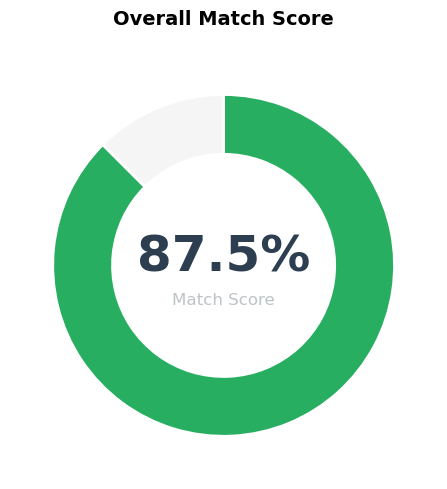

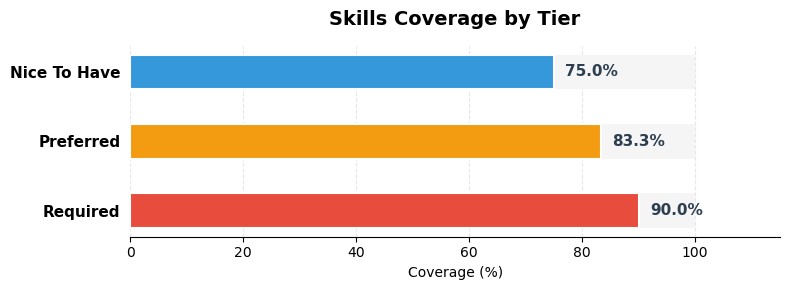

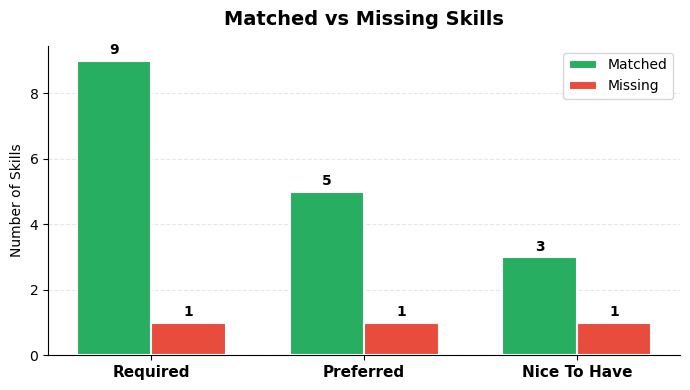

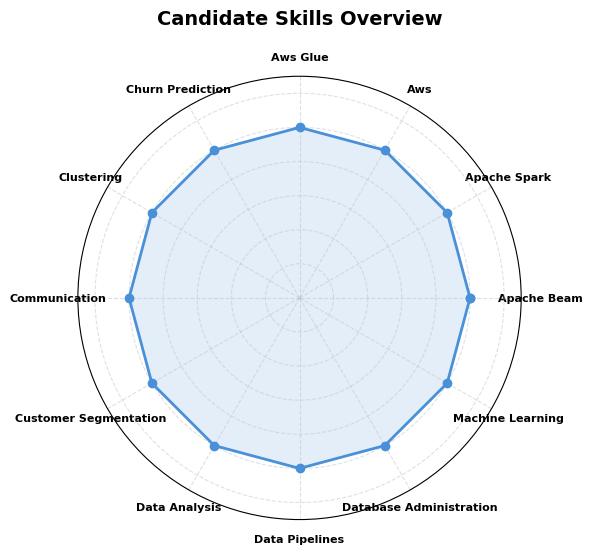


✅ All 4 charts generated and displayed.


In [11]:
tmp_dir = tempfile.mkdtemp(prefix='career_report_')
s       = score_result['overall_score']
bd      = score_result['breakdown']

# ── 1. Donut / Gauge Chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(aspect='equal'))
fig.patch.set_alpha(0)
donut_color = COLORS['success'] if s >= 80 else (COLORS['warning'] if s >= 60 else COLORS['danger'])
wedges, _ = ax.pie(
    [s, 100 - s],
    colors=[hex_to_float_rgb(donut_color), hex_to_float_rgb(COLORS['light_gray'])],
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2)
)
ax.text(0,  0.05, f'{s}%',       ha='center', va='center', fontsize=36, fontweight='bold',
        color=hex_to_float_rgb(COLORS['dark_gray']))
ax.text(0, -0.20, 'Match Score', ha='center', va='center', fontsize=12,
        color=hex_to_float_rgb(COLORS['mid_gray']))
ax.set_title('Overall Match Score', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
donut_path = os.path.join(tmp_dir, 'donut.png')
fig.savefig(donut_path, dpi=200, bbox_inches='tight', transparent=True)
plt.show()

# ── 2. Tier Coverage Bar Chart ───────────────────────────────────────────────
tier_color_map = {'required': COLORS['tier_required'], 'preferred': COLORS['tier_preferred'], 'nice_to_have': COLORS['tier_nice']}
tier_labels, coverage_values, bar_colors = [], [], []
for tier in ['required', 'preferred', 'nice_to_have']:
    if tier in bd:
        tier_labels.append(tier.replace('_', ' ').title())
        coverage_values.append(bd[tier]['tier_pct'])
        bar_colors.append(hex_to_float_rgb(tier_color_map[tier]))

fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor('white')
y_pos = np.arange(len(tier_labels))
ax.barh(y_pos, [100]*len(tier_labels), height=0.5, color=hex_to_float_rgb(COLORS['light_gray']), zorder=2)
ax.barh(y_pos, coverage_values, height=0.5, color=bar_colors, edgecolor='white', linewidth=1.5, zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(tier_labels, fontsize=11, fontweight='bold')
ax.set_xlim(0, 115)
ax.set_xlabel('Coverage (%)', fontsize=10)
ax.set_title('Skills Coverage by Tier', fontsize=14, fontweight='bold', pad=15)
for i, v in enumerate(coverage_values):
    ax.text(v + 2, i, f'{v:.1f}%', va='center', ha='left', fontsize=11, fontweight='bold',
            color=hex_to_float_rgb(COLORS['dark_gray']))
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
tier_bar_path = os.path.join(tmp_dir, 'tier_bar.png')
fig.savefig(tier_bar_path, dpi=200, bbox_inches='tight')
plt.show()

# ── 3. Matched vs Missing Grouped Bar Chart ──────────────────────────────────
tiers  = ['required', 'preferred', 'nice_to_have']
labels = [t.replace('_', ' ').title() for t in tiers]
matched_counts = [len(bd[t]['matched']) for t in tiers]
missing_counts = [len(bd[t]['missing']) for t in tiers]
x, width = np.arange(len(labels)), 0.35

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('white')
bars1 = ax.bar(x - width/2, matched_counts, width, label='Matched',
               color=hex_to_float_rgb(COLORS['success']), edgecolor='white', linewidth=1.5, zorder=3)
bars2 = ax.bar(x + width/2, missing_counts, width, label='Missing',
               color=hex_to_float_rgb(COLORS['danger']),  edgecolor='white', linewidth=1.5, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Skills', fontsize=10)
ax.set_title('Matched vs Missing Skills', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right')
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.1, str(int(h)),
                ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
matched_missing_path = os.path.join(tmp_dir, 'matched_missing.png')
fig.savefig(matched_missing_path, dpi=200, bbox_inches='tight')
plt.show()

# ── 4. Skills Radar Chart ────────────────────────────────────────────────────
skills_list = sorted(list(candidate_skills))[:12]
N           = len(skills_list)
angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values      = [1.0] * N
angles     += angles[:1]
values     += values[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')
ax.plot(angles, values, 'o-', linewidth=2, color=hex_to_float_rgb(COLORS['accent']))
ax.fill(angles, values, alpha=0.15, color=hex_to_float_rgb(COLORS['accent']))
ax.set_xticks(angles[:-1])
ax.set_xticklabels([s.title() for s in skills_list], fontsize=8, fontweight='bold')
ax.set_ylim(0, 1.3)
ax.set_yticklabels([])
ax.grid(color=hex_to_float_rgb(COLORS['mid_gray']), linestyle='--', alpha=0.5)
ax.set_title('Candidate Skills Overview', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
radar_path = os.path.join(tmp_dir, 'radar.png')
fig.savefig(radar_path, dpi=200, bbox_inches='tight')
plt.show()

print('\n✅ All 4 charts generated and displayed.')

### 10c — PDF Helper Functions

In [12]:
def sanitize_text(text: str) -> str:
    """Remove/replace characters that Helvetica (latin-1) cannot render."""
    replacements = {
        '\u2014': '-',  '\u2013': '-',
        '\u2018': "'", '\u2019': "'",
        '\u201c': '"', '\u201d': '"',
        '\u2022': '*', '\u2026': '...',
        '\u2192': '->', '\u2190': '<-',
    }
    result = []
    for ch in text:
        ch = replacements.get(ch, ch)
        try:
            ch.encode('latin-1')
            result.append(ch)
        except UnicodeEncodeError:
            result.append('')
    return ''.join(result)


def clean_markdown_text(text: str) -> str:
    """
    Strip common Markdown syntax, returning plain text.
    FIX: use r'\1' (backreference) not r'\\1' (literal backslash-1).
    """
    text = re.sub(r'\*\*([^*]+)\*\*',      r'\1', text)  # **bold**
    text = re.sub(r'\*([^*]+)\*',           r'\1', text)  # *italic*
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)  # [label](url)
    text = re.sub(r'`([^`]*)`',             r'\1', text)  # `code`
    text = text.replace('`', '')
    return text.strip()


def parse_roadmap_markdown(roadmap_text: str) -> list:
    """
    Parse Markdown roadmap into structured sections.
    Handles ### sections, #### subsections, and both - and * bullet styles.
    """
    sections           = []
    current_section    = None
    current_subsection = None

    for raw_line in roadmap_text.split('\n'):
        stripped = raw_line.strip()
        if not stripped:
            continue

        if stripped.startswith('### '):
            if current_subsection and current_section:
                current_section['subsections'].append(current_subsection)
                current_subsection = None
            if current_section:
                sections.append(current_section)
            current_section = {'title': clean_markdown_text(stripped[4:]), 'items': [], 'subsections': []}

        elif stripped.startswith('#### '):
            if current_subsection and current_section:
                current_section['subsections'].append(current_subsection)
            current_subsection = {'title': clean_markdown_text(stripped[5:]), 'items': []}

        elif stripped.startswith('- ') or stripped.startswith('* '):
            content = clean_markdown_text(stripped[2:])
            if current_subsection:
                current_subsection['items'].append(content)
            elif current_section:
                current_section['items'].append(content)

        else:
            content = clean_markdown_text(stripped)
            if content:
                if current_subsection:
                    current_subsection['items'].append(content)
                elif current_section:
                    current_section['items'].append(content)

    # Flush remaining
    if current_subsection and current_section:
        current_section['subsections'].append(current_subsection)
    if current_section:
        sections.append(current_section)

    return sections


print('✅ PDF helper functions ready.')

✅ PDF helper functions ready.


### 10d — PDF Class Definition

In [13]:
# FIX: replace deprecated ln=True/False with new_x/new_y enums (fpdf2 >= 2.5.2)

class CareerReportPDF(FPDF):
    def __init__(self, candidate_name='', target_role=''):
        super().__init__('P', 'mm', 'A4')
        self.candidate_name = candidate_name
        self.target_role    = target_role
        self.set_auto_page_break(auto=True, margin=25)

    def header(self):
        if self.page_no() == 1:
            return
        self.set_font('Helvetica', 'B', 8)
        r, g, b = hex_to_rgb(COLORS['mid_gray'])
        self.set_text_color(r, g, b)
        self.cell(0, 8, sanitize_text(f'Career Analysis Report - {self.candidate_name}'),
                  new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        r, g, b = hex_to_rgb(COLORS['accent'])
        self.set_draw_color(r, g, b)
        self.set_line_width(0.5)
        self.line(10, 13, 200, 13)
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 8)
        r, g, b = hex_to_rgb(COLORS['mid_gray'])
        self.set_text_color(r, g, b)
        self.cell(0, 10, f'Page {self.page_no()}/{{nb}}', align='C')

    def section_title(self, title: str):
        self.set_font('Helvetica', 'B', 16)
        r, g, b = hex_to_rgb(COLORS['primary'])
        self.set_text_color(r, g, b)
        self.cell(0, 12, sanitize_text(title), new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        r, g, b = hex_to_rgb(COLORS['accent'])
        self.set_draw_color(r, g, b)
        self.set_line_width(0.8)
        self.line(self.l_margin, self.get_y(), 100, self.get_y())
        self.ln(6)

    def sub_title(self, title: str):
        self.set_font('Helvetica', 'B', 13)
        r, g, b = hex_to_rgb(COLORS['dark_gray'])
        self.set_text_color(r, g, b)
        self.cell(0, 10, sanitize_text(title), new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        self.ln(2)

    def body_text(self, text: str, bold: bool = False):
        self.set_font('Helvetica', 'B' if bold else '', 10)
        r, g, b = hex_to_rgb(COLORS['dark_gray'])
        self.set_text_color(r, g, b)
        self.multi_cell(0, 6, sanitize_text(text))
        self.ln(2)

    def info_row(self, label: str, value: str):
        self.set_font('Helvetica', 'B', 10)
        r, g, b = hex_to_rgb(COLORS['primary'])
        self.set_text_color(r, g, b)
        self.cell(50, 7, sanitize_text(label), new_x=XPos.RIGHT, new_y=YPos.TOP)
        self.set_font('Helvetica', '', 10)
        r, g, b = hex_to_rgb(COLORS['dark_gray'])
        self.set_text_color(r, g, b)
        self.cell(0, 7, sanitize_text(value), new_x=XPos.LMARGIN, new_y=YPos.NEXT)

    def skill_badge(self, skill: str, is_matched: bool = True):
        color = COLORS['success'] if is_matched else COLORS['danger']
        icon  = '[+]' if is_matched else '[-]'
        self.set_font('Helvetica', '', 9)
        r, g, b = hex_to_rgb(color)
        self.set_text_color(r, g, b)
        self.cell(0, 5, sanitize_text(f'  {icon}  {skill.title()}'),
                  new_x=XPos.LMARGIN, new_y=YPos.NEXT)

    def roadmap_item(self, text: str):
        self.set_font('Helvetica', '', 10)
        r, g, b = hex_to_rgb(COLORS['dark_gray'])
        self.set_text_color(r, g, b)
        self.set_x(self.l_margin + 6)
        self.multi_cell(0, 5, sanitize_text('* ' + text))
        self.ln(1)


print('✅ CareerReportPDF class ready.')

✅ CareerReportPDF class ready.


### 10e — Build & Save PDF Report

In [14]:
data = strategist_output

pdf = CareerReportPDF(
    candidate_name=data['candidate']['name'],
    target_role=data['target_role']['title']
)
pdf.alias_nb_pages()

# ── PAGE 1: Cover ────────────────────────────────────────────────────────────
pdf.add_page()
pdf.ln(20)
pdf.set_font('Helvetica', 'B', 28)
r, g, b = hex_to_rgb(COLORS['primary'])
pdf.set_text_color(r, g, b)
pdf.cell(0, 15, 'Career Analysis Report', align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.set_font('Helvetica', '', 12)
r, g, b = hex_to_rgb(COLORS['mid_gray'])
pdf.set_text_color(r, g, b)
pdf.cell(0, 8, 'AI-Powered Skills Gap Analysis & Learning Roadmap',
         align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.ln(5)
r, g, b = hex_to_rgb(COLORS['accent'])
pdf.set_draw_color(r, g, b)
pdf.set_line_width(1)
pdf.line(60, pdf.get_y(), 150, pdf.get_y())
pdf.ln(12)

pdf.set_font('Helvetica', 'B', 13)
r, g, b = hex_to_rgb(COLORS['dark_gray'])
pdf.set_text_color(r, g, b)
pdf.cell(0, 8, 'Candidate Profile', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.ln(2)
pdf.info_row('Name:',         data['candidate']['name'])
pdf.info_row('Current Title:', data['candidate']['title'])
pdf.info_row('Total Skills:',  str(len(data['candidate']['skills_found'])))
pdf.ln(4)
pdf.set_font('Helvetica', 'B', 13)
r, g, b = hex_to_rgb(COLORS['dark_gray'])
pdf.set_text_color(r, g, b)
pdf.cell(0, 8, 'Target Role', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.ln(2)
pdf.info_row('Position:', data['target_role']['title'])
pdf.info_row('Company:',  data['target_role']['company'])
pdf.ln(8)

if os.path.exists(donut_path):
    img_w = 65
    pdf.image(donut_path, x=(210 - img_w) / 2, y=pdf.get_y(), w=img_w)
    pdf.ln(70)

pdf.set_font('Helvetica', 'I', 9)
r, g, b = hex_to_rgb(COLORS['mid_gray'])
pdf.set_text_color(r, g, b)
pdf.cell(0, 8, f"Generated on {datetime.now().strftime('%B %d, %Y at %H:%M')}",
         align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)

# ── PAGE 2: Skills Breakdown ─────────────────────────────────────────────────
pdf.add_page()
pdf.section_title('Skills Match Breakdown')
overall = data['match_score']['overall']
bd_pdf  = data['match_score']['breakdown']
pdf.body_text(f'Overall match score: {overall}%. Below is the detailed breakdown by skill tier.')

if os.path.exists(tier_bar_path):
    pdf.image(tier_bar_path, x=15, w=180)
    pdf.ln(5)
if os.path.exists(matched_missing_path):
    pdf.image(matched_missing_path, x=25, w=155)
    pdf.ln(5)

pdf.sub_title('[+] Matched Skills')
for tier in ['required', 'preferred', 'nice_to_have']:
    if tier in bd_pdf and bd_pdf[tier]['matched']:
        label = tier.replace('_', ' ').title()
        pdf.set_font('Helvetica', 'B', 10)
        r, g, b = hex_to_rgb(COLORS['primary'])
        pdf.set_text_color(r, g, b)
        pdf.cell(0, 6, sanitize_text(f'  {label}:'), new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        for skill in bd_pdf[tier]['matched']:
            pdf.skill_badge(skill, is_matched=True)
        pdf.ln(2)

pdf.sub_title('[-] Missing Skills (Gap)')
for tier in ['required', 'preferred', 'nice_to_have']:
    if tier in bd_pdf and bd_pdf[tier]['missing']:
        label = tier.replace('_', ' ').title()
        pdf.set_font('Helvetica', 'B', 10)
        r, g, b = hex_to_rgb(COLORS['primary'])
        pdf.set_text_color(r, g, b)
        pdf.cell(0, 6, sanitize_text(f'  {label}:'), new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        for skill in bd_pdf[tier]['missing']:
            pdf.skill_badge(skill, is_matched=False)
        pdf.ln(2)

# ── PAGE 3: Skills Radar + Inventory ────────────────────────────────────────
pdf.add_page()
pdf.section_title('Candidate Skills Overview')
skills_all = data['candidate']['skills_found']
pdf.body_text(f"{data['candidate']['name']} has {len(skills_all)} identified skills "
              'across technical, tools, and soft skills categories.')

if os.path.exists(radar_path):
    img_w = 140
    pdf.image(radar_path, x=(210 - img_w) / 2, w=img_w)
    pdf.ln(5)

pdf.sub_title('Complete Skills Inventory')
sorted_skills = sorted(skills_all)
col_width = 60
x_start   = pdf.l_margin
pdf.set_font('Helvetica', '', 9)
r, g, b = hex_to_rgb(COLORS['dark_gray'])
pdf.set_text_color(r, g, b)
for i, skill in enumerate(sorted_skills):
    col = i % 3
    if col == 0 and i > 0:
        pdf.ln(5)
    pdf.set_x(x_start + col * col_width)
    pdf.cell(col_width, 5, f'  * {skill.title()}', new_x=XPos.RIGHT, new_y=YPos.TOP)
pdf.ln(10)

# ── PAGE 4+: Learning Roadmap ────────────────────────────────────────────────
pdf.add_page()
pdf.section_title('30-Day Learning Roadmap')
roadmap_text = data.get('roadmap_markdown', '')

if roadmap_text:
    sections = parse_roadmap_markdown(roadmap_text)
    for section in sections:
        if pdf.get_y() > 240:
            pdf.add_page()
        pdf.sub_title(section['title'])
        for item in section['items']:
            pdf.roadmap_item(item)
        for subsection in section['subsections']:
            if pdf.get_y() > 250:
                pdf.add_page()
            pdf.set_font('Helvetica', 'B', 11)
            r, g, b = hex_to_rgb(COLORS['accent'])
            pdf.set_text_color(r, g, b)
            pdf.cell(0, 8, sanitize_text(f"  {subsection['title']}"),
                     new_x=XPos.LMARGIN, new_y=YPos.NEXT)
            for item in subsection['items']:
                pdf.roadmap_item(item)
        pdf.ln(4)
else:
    pdf.body_text('No roadmap data available.')

# ── Save ─────────────────────────────────────────────────────────────────────
output_path = 'career_analysis_report.pdf'
pdf.output(output_path)

file_size = os.path.getsize(output_path)
print(f'\n📄 PDF saved to: {output_path}')
print(f'   File size:    {file_size:,} bytes ({file_size / 1024:.1f} KB)')
print(f'   Total pages:  {pdf.page_no()}')

shutil.rmtree(tmp_dir, ignore_errors=True)
print('\n✅ Career analysis report generated successfully!')


📄 PDF saved to: career_analysis_report.pdf
   File size:    300,418 bytes (293.4 KB)
   Total pages:  7

✅ Career analysis report generated successfully!
